# One Trial (5 Agents) Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Path
csv_path = "one_trial_5_agents_agent_steps.csv"

# Plot defaults
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.grid"] = True

## Load and Inspect Data

In [2]:
df = pd.read_csv(csv_path)

# Sort for clean time-series plotting
sort_cols = [c for c in ["agent_id", "time", "step"] if c in df.columns]
df = df.sort_values(sort_cols).reset_index(drop=True)

agent_ids = sorted(df["agent_id"].unique())

print("rows:", len(df))
print("agents:", agent_ids)
print("time range:", df["time"].min(), "->", df["time"].max())
print("steps range:", df["step"].min(), "->", df["step"].max())
print("columns:", list(df.columns))

# Color map for agent lines
cmap = plt.cm.tab10
agent_colors = {aid: cmap(i % 10) for i, aid in enumerate(agent_ids)}

rows: 7280
agents: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
time range: 0.1 -> 145.6
steps range: 1 -> 1456
columns: ['step', 'time', 'agent_id', 'x', 'y', 'vx', 'vy', 'ax', 'ay', 'speed', 'acceleration_magnitude', 'field_value', 'field_delta', 'neighbor_count', 'nearest_neighbor_distance', 'mean_neighbor_distance', 'avoidance_gain', 'quark_gain', 'directional_derivative_gain', 'linear_drag_gain', 'action_avoidance', 'action_quark', 'action_directional_derivative', 'action_linear_drag']


## Helper: Time-Series Plotter (time on x-axis)

In [3]:
def plot_metrics_over_time(df, metrics, title, ncols=2, ylim=None):
    metrics = [m for m in metrics if m in df.columns]
    if not metrics:
        print("No matching metrics found for:", title)
        return

    nrows = int(np.ceil(len(metrics) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 3.5 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, metric in zip(axes, metrics):
        for aid in agent_ids:
            agent_df = df[df["agent_id"] == aid]
            ax.plot(
                agent_df["time"],
                agent_df[metric],
                label=f"agent {aid}",
                color=agent_colors[aid],
                alpha=0.85,
            )
        ax.set_title(metric)
        ax.set_xlabel("time")
        ax.set_ylabel(metric)
        if ylim is not None:
            ax.set_ylim(ylim)

    for ax in axes[len(metrics):]:
        ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(5, len(agent_ids)))
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

## Environment Inputs Over Time (per agent)

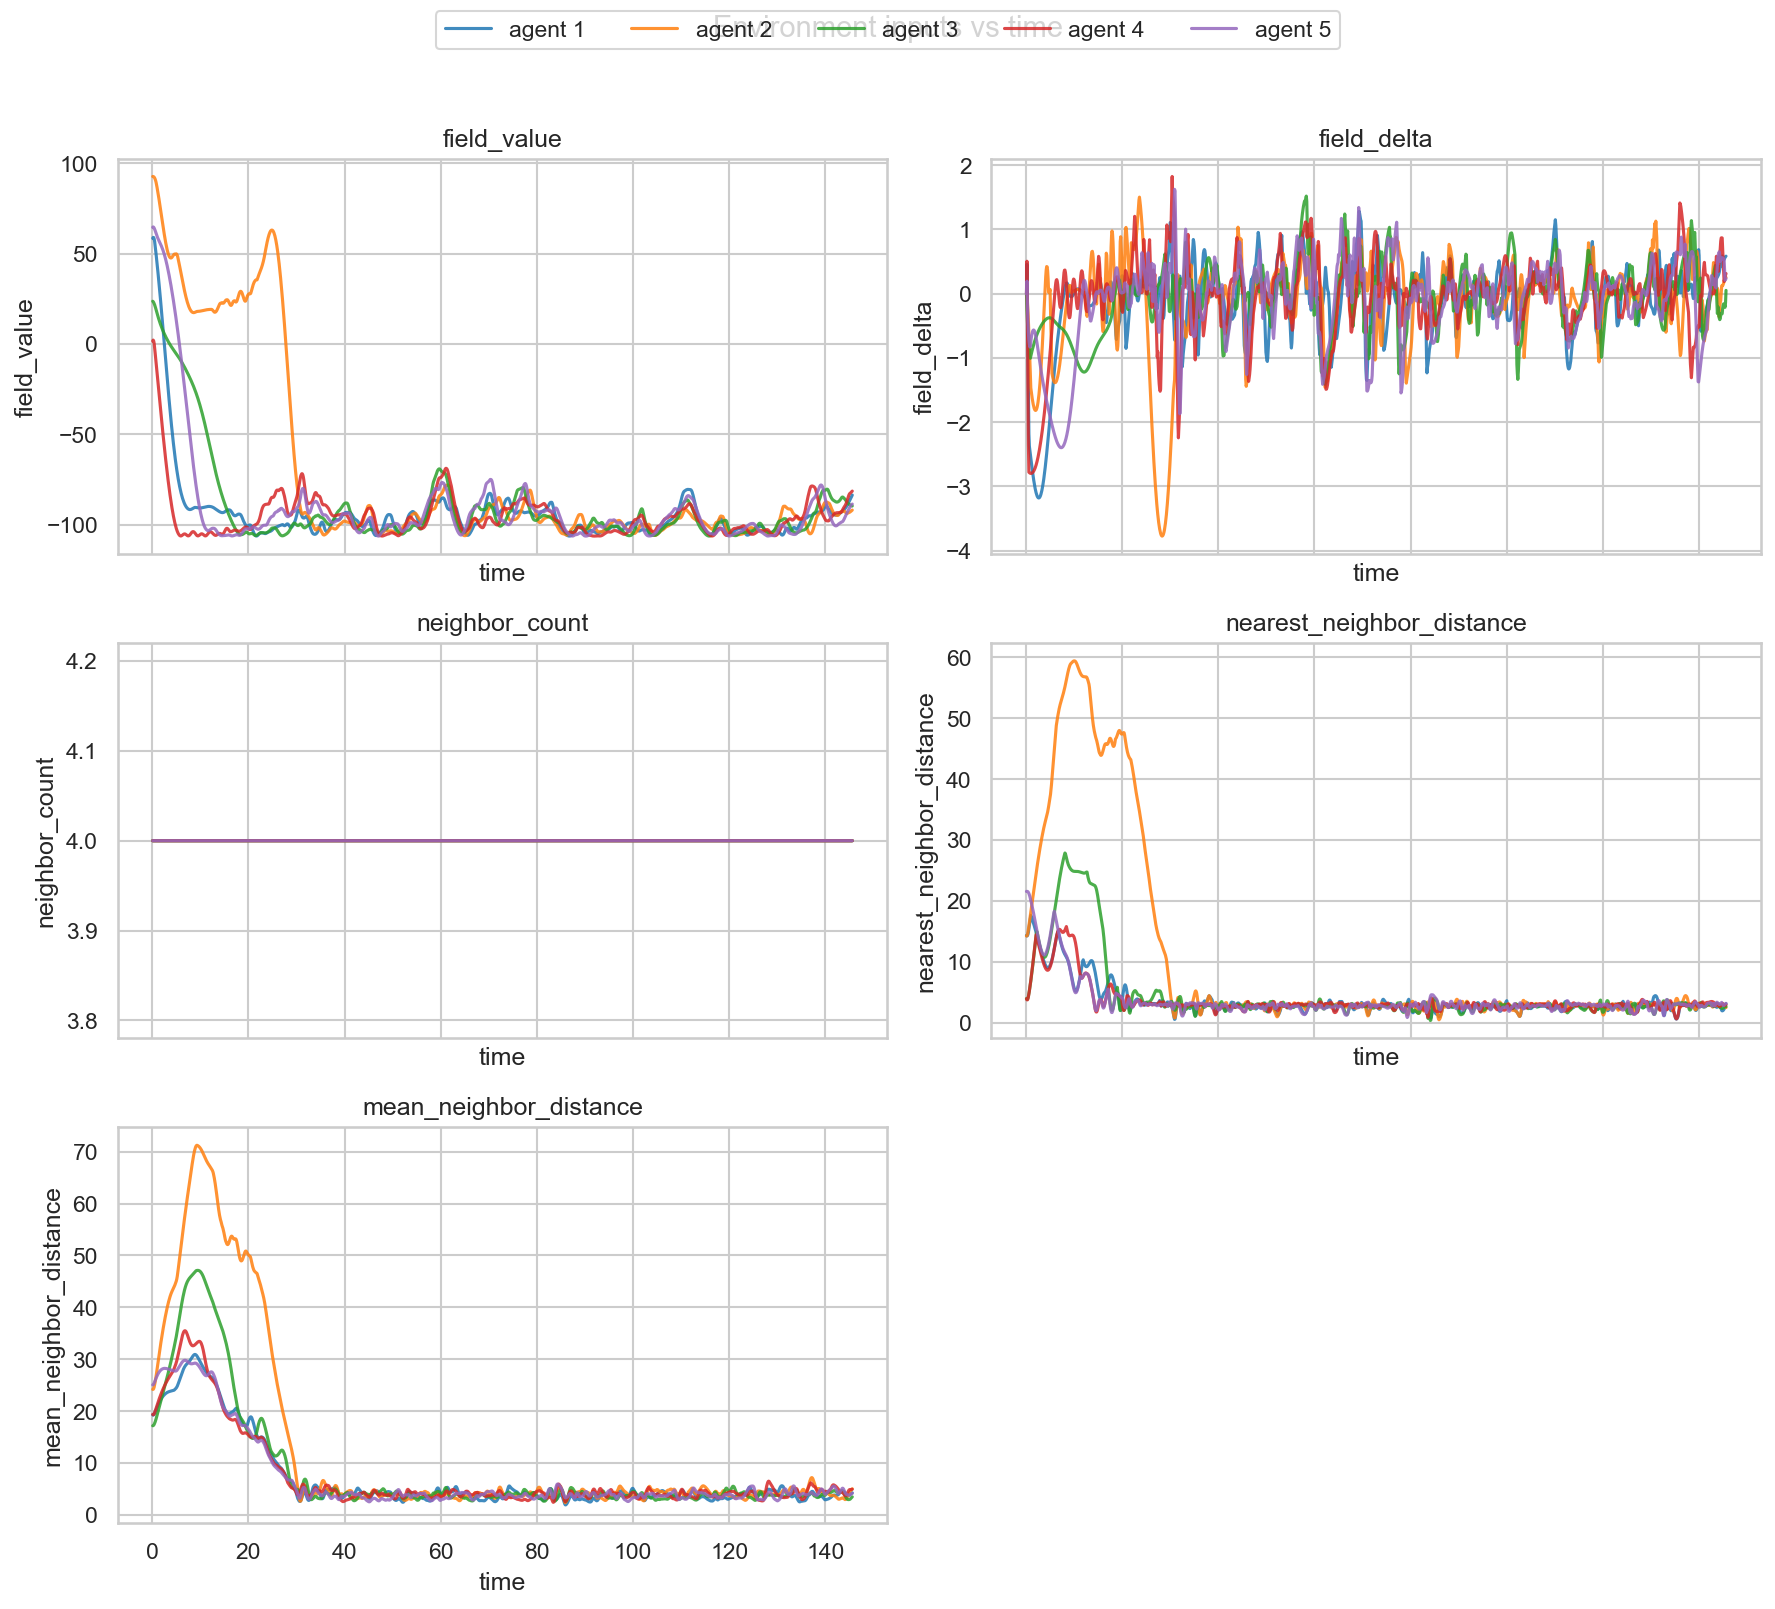

In [4]:
env_metrics = [
    "field_value",
    "field_delta",
    "neighbor_count",
    "nearest_neighbor_distance",
    "mean_neighbor_distance",
]
plot_metrics_over_time(df, env_metrics, "Environment inputs vs time")

## Gain Trajectories (per agent)

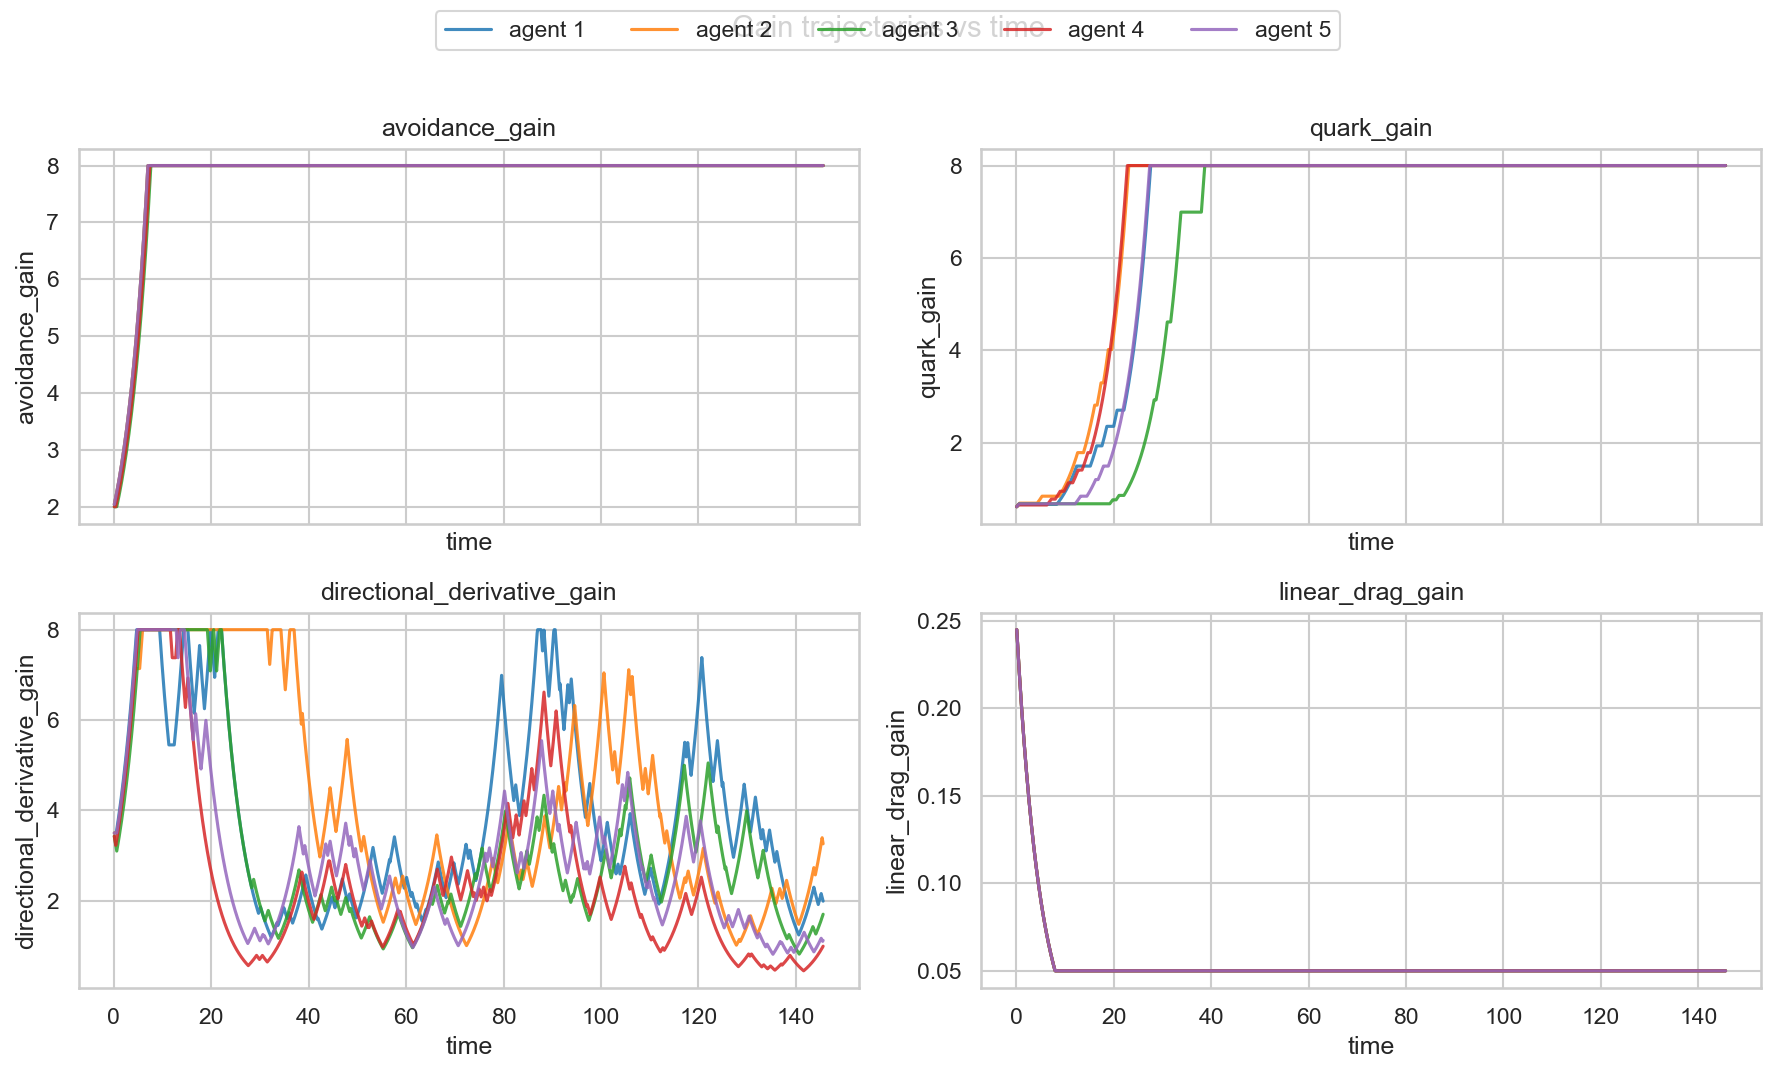

In [5]:
gain_metrics = [
    "avoidance_gain",
    "quark_gain",
    "directional_derivative_gain",
    "linear_drag_gain",
]
plot_metrics_over_time(df, gain_metrics, "Gain trajectories vs time")

## Action Signals (per agent)

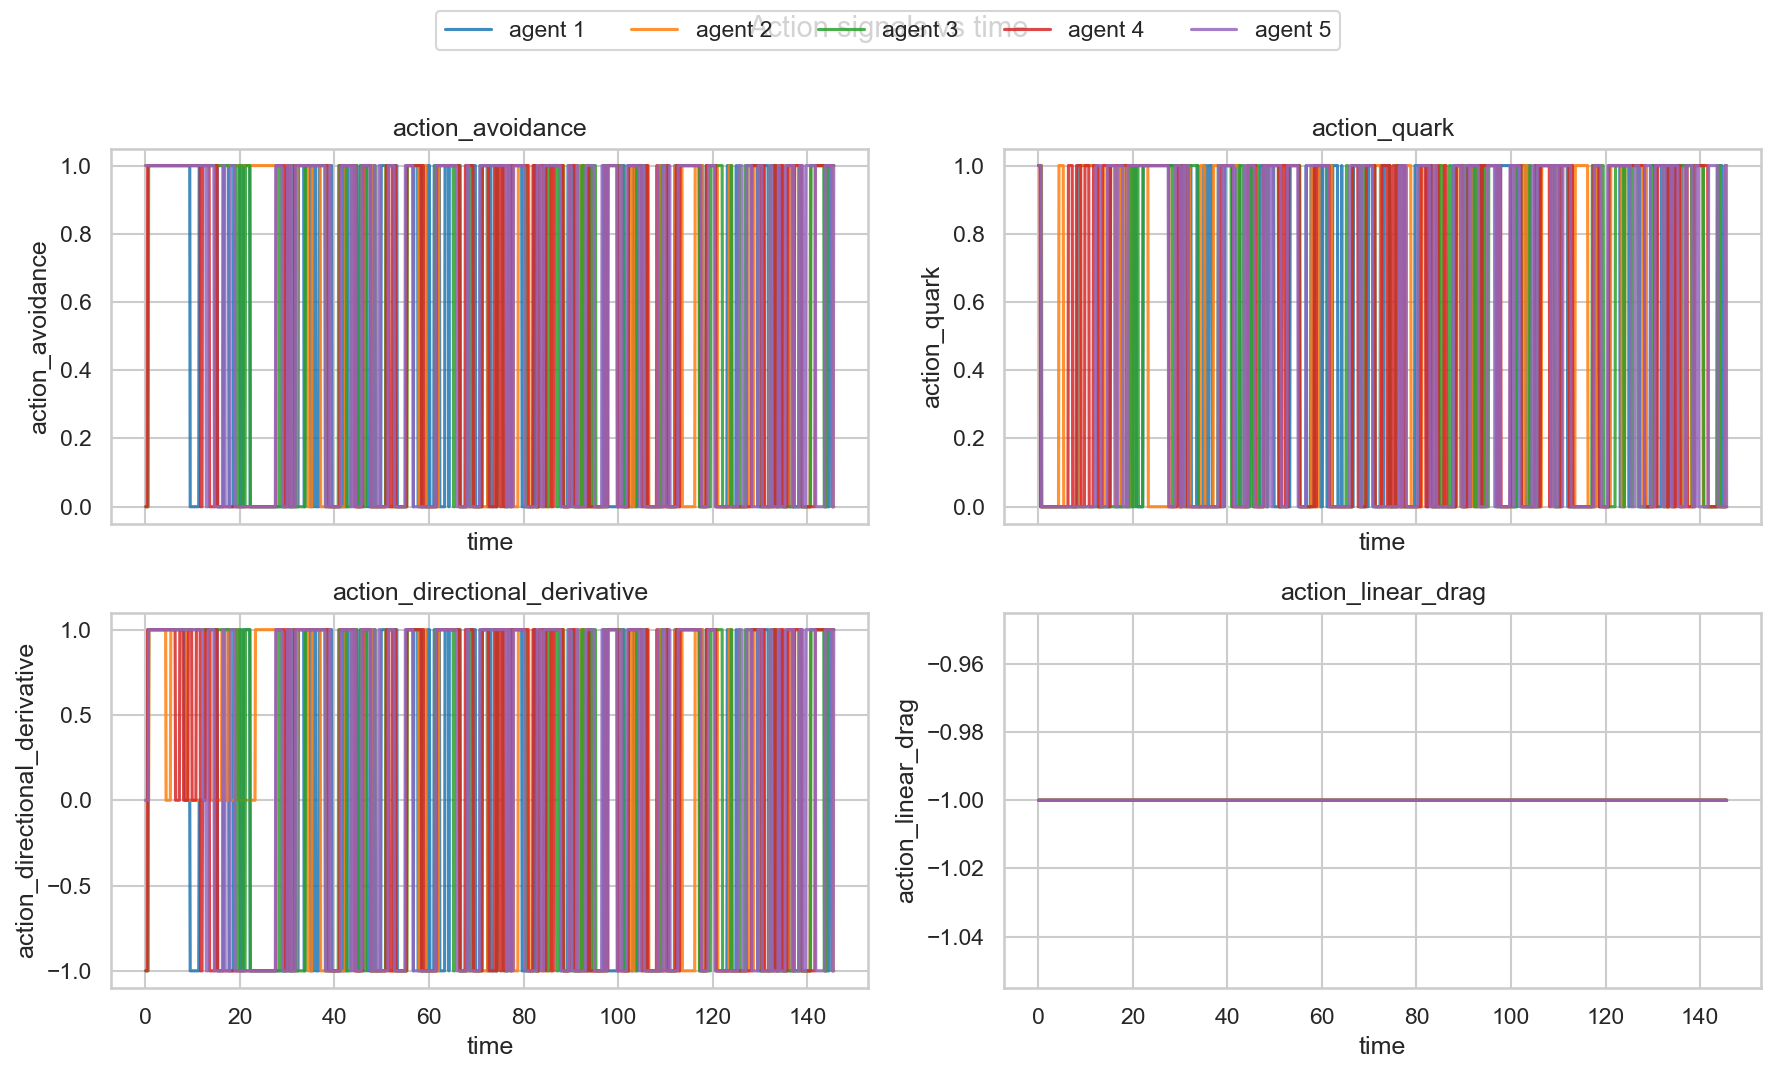

In [6]:
action_metrics = [
    "action_avoidance",
    "action_quark",
    "action_directional_derivative",
    "action_linear_drag",
]
plot_metrics_over_time(df, action_metrics, "Action signals vs time")

## Kinematics (per agent)

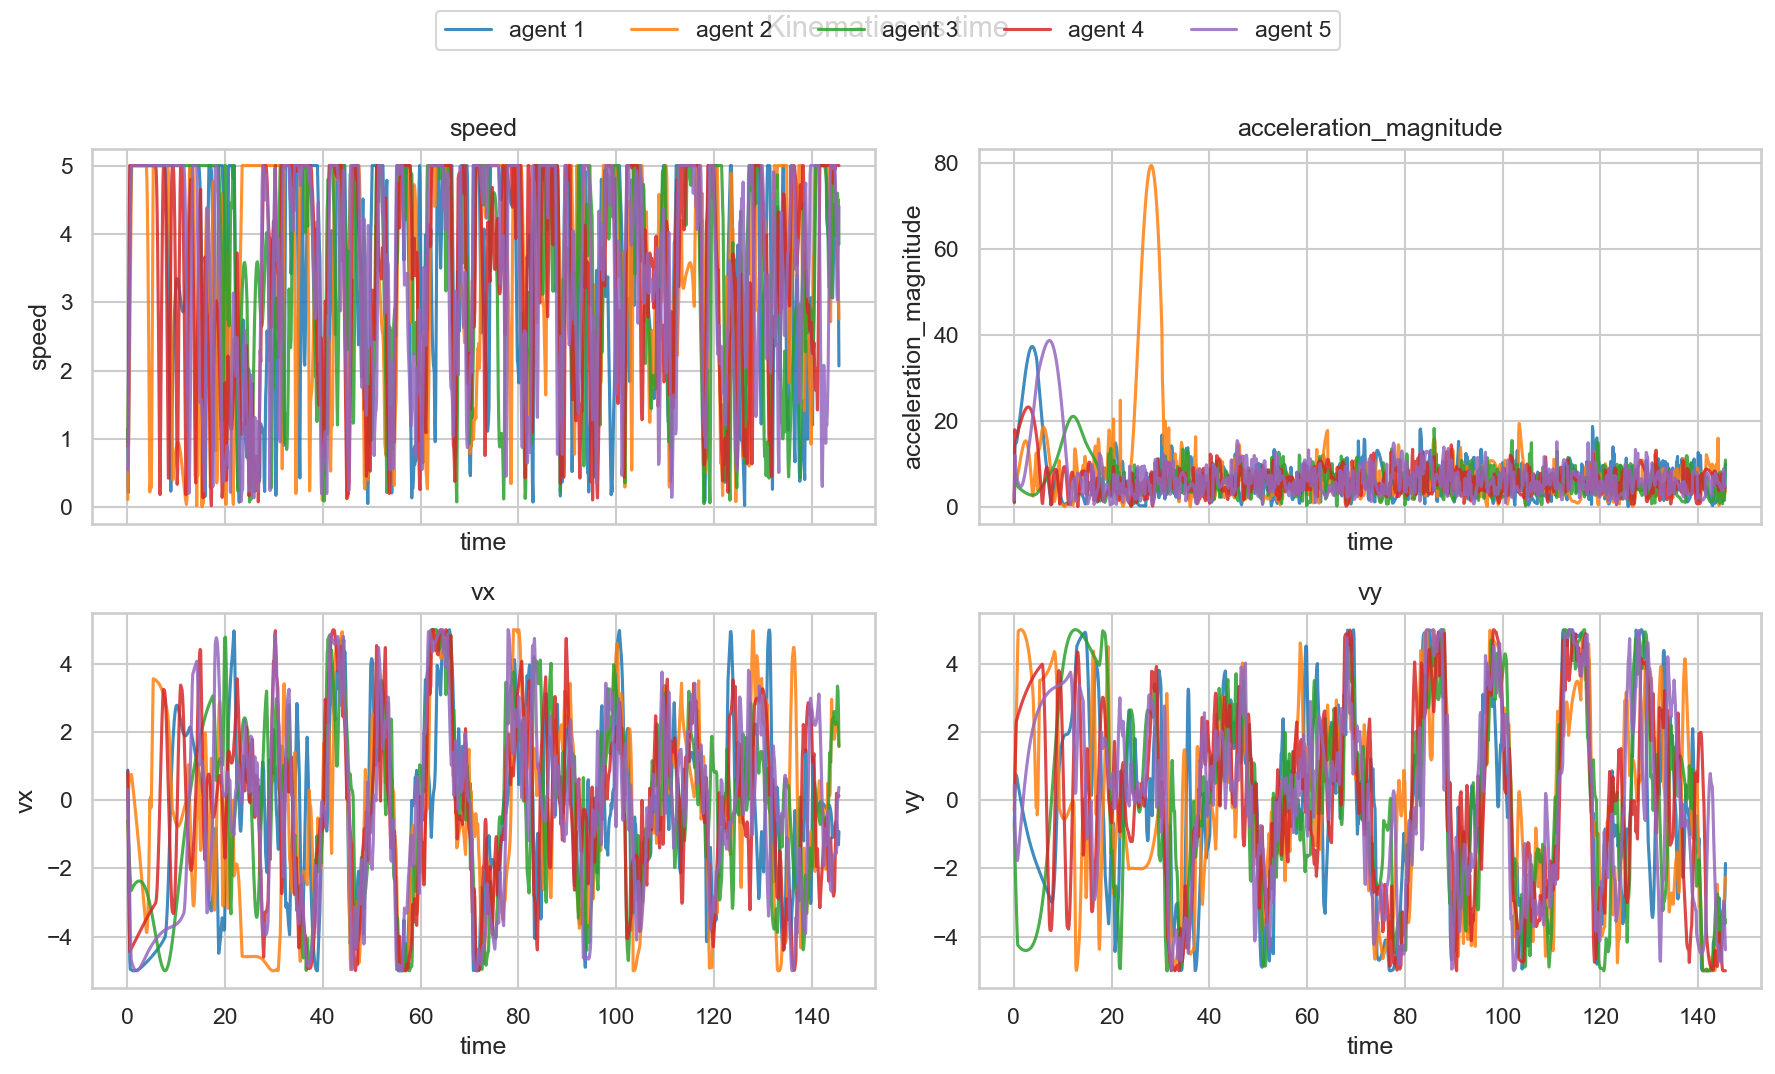

In [7]:
kin_metrics = [
    "speed",
    "acceleration_magnitude",
    "vx",
    "vy",
]
plot_metrics_over_time(df, kin_metrics, "Kinematics vs time")